In [1]:
# CELL 1 — IMPORTS AND LOAD PROCESSED DATA

import pandas as pd
import geopandas as gpd
import folium
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

BASE_PATH      = r"C:\Users\User\Desktop\Data Analysis\Nairobi Public Health Facility Access Analysis"
RAW_PATH       = os.path.join(BASE_PATH, "data", "raw")
PROCESSED_PATH = os.path.join(BASE_PATH, "data", "processed")
VISUALS_PATH   = os.path.join(BASE_PATH, "visuals")

# Load master analysis table
master = pd.read_csv(os.path.join(PROCESSED_PATH, "nairobi_master.csv"))

# Load GeoJSON
geo = gpd.read_file(os.path.join(RAW_PATH, "ken_admin2.geojson"))
nairobi_geo = geo[geo['adm1_name'] == 'Nairobi'].copy().reset_index(drop=True)

# Load facilities
facilities_raw = pd.read_excel(
    os.path.join(RAW_PATH, "kenya-health-facilities-2017_08_02.xlsx")
)
nairobi_fac = facilities_raw[
    facilities_raw['County'].str.upper() == 'NAIROBI'
].copy().reset_index(drop=True)
nairobi_fac['constituency'] = nairobi_fac['Constituency'].str.upper().str.strip()

print("Master shape:", master.shape)
print("GeoJSON shape:", nairobi_geo.shape)
print("Facilities shape:", nairobi_fac.shape)
print("\nAll loaded successfully.")

Master shape: (17, 20)
GeoJSON shape: (17, 27)
Facilities shape: (783, 23)

All loaded successfully.


In [2]:
# CELL 2 — MERGE MASTER WITH GEOJSON

# Standardise names for merge
nairobi_geo['constituency_upper'] = nairobi_geo['adm2_name'].str.upper().str.strip()
master['constituency_upper'] = master['constituency'].str.upper().str.strip()

# Fix LANGATA vs LANG'ATA mismatch
nairobi_geo['constituency_upper'] = nairobi_geo['constituency_upper'].replace(
    {'LANGATA': 'LANGATA'}
)

geo_master = nairobi_geo.merge(
    master,
    on='constituency_upper',
    how='left'
)

print("Merged shape:", geo_master.shape)
print("\nNull check on key columns:")
print(geo_master[['constituency_upper','HAII_normalised','rank',
                   'total_pop','total_facilities']].isnull().sum())
print("\nMerged table preview:")
print(geo_master[['constituency_upper','HAII_normalised',
                  'rank','confidence']].sort_values('rank').to_string())

Merged shape: (17, 48)

Null check on key columns:
constituency_upper    0
HAII_normalised       2
rank                  2
total_pop             2
total_facilities      2
dtype: int64

Merged table preview:
   constituency_upper  HAII_normalised  rank confidence
12            MATHARE           100.00   1.0       high
5       EMBAKASI WEST            36.55   2.0        low
4      EMBAKASI SOUTH            32.43   3.0        low
3      EMBAKASI NORTH            31.74   4.0        low
14            RUARAKA            25.41   5.0       high
6           KAMUKUNJI            19.35   6.0     medium
11           MAKADARA            13.75   7.0     medium
7            KASARANI            13.71   8.0       high
1    EMBAKASI CENTRAL            12.70   9.0        low
8               KIBRA             4.87  10.0       high
15            STAREHE             3.81  12.0     medium
13           ROYSAMBU             3.27  13.0     medium
16          WESTLANDS             2.66  15.0       high
2       E

In [3]:
# CELL 3 — FIX GEOJSON NAME MISMATCHES

# In the GeoJSON: 'KILIMANI' = Dagoretti North, 'DAGORETTI' = Dagoretti South
nairobi_geo['constituency_upper'] = nairobi_geo['constituency_upper'].replace({
    'KILIMANI'  : 'DAGORETTI NORTH',
    'DAGORETTI' : 'DAGORETTI SOUTH'
})

# Re-merge
geo_master = nairobi_geo.merge(
    master,
    on='constituency_upper',
    how='left'
)

print("Merged shape:", geo_master.shape)
print("\nNull check:")
print(geo_master[['constituency_upper','HAII_normalised','rank']].isnull().sum())
print("\nFull ranked table:")
print(geo_master[['constituency_upper','HAII_normalised','rank',
                  'confidence']].sort_values('rank').to_string())


Merged shape: (17, 48)

Null check:
constituency_upper    0
HAII_normalised       0
rank                  0
dtype: int64

Full ranked table:
   constituency_upper  HAII_normalised  rank confidence
12            MATHARE           100.00     1       high
5       EMBAKASI WEST            36.55     2        low
4      EMBAKASI SOUTH            32.43     3        low
3      EMBAKASI NORTH            31.74     4        low
14            RUARAKA            25.41     5       high
6           KAMUKUNJI            19.35     6     medium
11           MAKADARA            13.75     7     medium
7            KASARANI            13.71     8       high
1    EMBAKASI CENTRAL            12.70     9        low
8               KIBRA             4.87    10       high
9     DAGORETTI NORTH             4.49    11     medium
15            STAREHE             3.81    12     medium
13           ROYSAMBU             3.27    13     medium
0     DAGORETTI SOUTH             2.97    14     medium
16          WESTLAN

In [7]:
# CELL 5 — IMPROVED CHOROPLETH WITH CUSTOM BINS

m2 = folium.Map(
    location=nairobi_centre,
    zoom_start=11,
    tiles='CartoDB positron'
)

folium.Choropleth(
    geo_data=geo_map,
    name='HAII Score',
    data=geo_map,
    columns=['constituency_upper', 'HAII_normalised'],
    key_on='feature.properties.constituency_upper',
    fill_color='RdYlGn_r',
    fill_opacity=0.8,
    line_opacity=0.6,
    legend_name='Healthcare Access Inequality Index (0=best, 100=worst)',
    bins=[0, 5, 10, 15, 20, 30, 40, 100],
    highlight=True
).add_to(m2)

tooltip = folium.GeoJsonTooltip(
    fields=['constituency_upper','HAII_normalised','rank',
            'total_pop','total_facilities','facility_density','confidence'],
    aliases=['Constituency','HAII Score','Rank',
             'Population','Facilities','Facilities per 10k','Data Confidence'],
    localize=True,
    sticky=True
)

folium.GeoJson(
    geo_map,
    tooltip=tooltip,
    style_function=lambda x: {
        'fillOpacity': 0,
        'color': 'black',
        'weight': 0.8
    }
).add_to(m2)

# Add constituency name labels
for _, row in geo_map.iterrows():
    folium.Marker(
        location=[row.geometry.centroid.y, row.geometry.centroid.x],
        icon=folium.DivIcon(
            html=f'<div style="font-size:8px; font-weight:bold; color:black; '
                 f'white-space:nowrap;">{row["constituency_upper"]}</div>',
            icon_size=(120, 20),
            icon_anchor=(60, 10)
        )
    ).add_to(m2)

folium.LayerControl().add_to(m2)

map_path2 = os.path.join(BASE_PATH, "visuals", "02_haii_choropleth_binned.html")
m2.save(map_path2)
print("Improved choropleth saved:", map_path2)

Improved choropleth saved: C:\Users\User\Desktop\Data Analysis\Nairobi Public Health Facility Access Analysis\visuals\02_haii_choropleth_binned.html


In [8]:
# CELL 6 — FACILITY POINT MAP (HOSPITALS VS DISPENSARIES)

# Filter and prepare coordinates
fac_map = nairobi_fac.dropna(subset=['Latitude', 'Longitude']).copy()

print("Facilities with coordinates:", len(fac_map))
print("Facilities without coordinates:", len(nairobi_fac) - len(fac_map))

# Colour and size per KEPH level
keph_style = {
    'Level 2': {'color': '#2196F3', 'radius': 4,  'label': 'Level 2 - Dispensary/Clinic'},
    'Level 3': {'color': '#FF9800', 'radius': 6,  'label': 'Level 3 - Health Centre'},
    'Level 4': {'color': '#F44336', 'radius': 9,  'label': 'Level 4 - County Hospital'},
    'Level 5': {'color': '#9C27B0', 'radius': 12, 'label': 'Level 5 - Regional Referral'},
    'Level 6': {'color': '#000000', 'radius': 15, 'label': 'Level 6 - National Referral'},
}

m3 = folium.Map(
    location=nairobi_centre,
    zoom_start=11,
    tiles='CartoDB positron'
)

# Add constituency boundaries as base layer
folium.GeoJson(
    geo_map,
    style_function=lambda x: {
        'fillColor'   : 'transparent',
        'color'       : 'black',
        'weight'      : 1.5,
        'fillOpacity' : 0
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['constituency_upper'],
        aliases=['Constituency']
    )
).add_to(m3)

# Add facility points
for _, row in fac_map.iterrows():
    level = row['Keph level'] if pd.notna(row['Keph level']) else 'Level 2'
    style = keph_style.get(level, keph_style['Level 2'])

    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=style['radius'],
        color=style['color'],
        fill=True,
        fill_color=style['color'],
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row['Name']}</b><br>"
            f"Level: {level}<br>"
            f"Type: {row['Facility type']}<br>"
            f"Owner: {row['Owner']}<br>"
            f"Constituency: {row['constituency']}",
            max_width=250
        )
    ).add_to(m3)

# Manual legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background-color: white; padding: 12px; border-radius: 8px;
     border: 1px solid grey; font-size: 12px;">
<b>Facility Level</b><br>
"""
for level, style in keph_style.items():
    legend_html += (
        f'<i style="background:{style["color"]};width:12px;height:12px;'
        f'border-radius:50%;display:inline-block;margin-right:6px;"></i>'
        f'{style["label"]}<br>'
    )
legend_html += "</div>"

m3.get_root().html.add_child(folium.Element(legend_html))

map_path3 = os.path.join(BASE_PATH, "visuals", "03_facility_points.html")
m3.save(map_path3)
print("Facility point map saved:", map_path3)

KeyError: ['Latitude', 'Longitude']

In [9]:
# CELL 6 FIX — CHECK COORDINATE COLUMNS

print("All columns in nairobi_fac:")
for col in nairobi_fac.columns:
    print(f"  '{col}'")

All columns in nairobi_fac:
  'Code'
  'Name'
  'Registration_number'
  'Keph level'
  'Facility type'
  'Owner'
  'Regulatory body'
  'Beds'
  'Cots'
  'County'
  'Constituency'
  'Sub county'
  'Ward'
  'Operation status'
  'Open_whole_day'
  'Open_public_holidays'
  'Open_weekends'
  'Open_late_night'
  'Service_names'
  'Approved'
  'Public visible'
  'Closed'
  'constituency'


In [10]:
# CELL 6 — FACILITY LEVEL BREAKDOWN MAP PER CONSTITUENCY

m3 = folium.Map(
    location=nairobi_centre,
    zoom_start=11,
    tiles='CartoDB positron'
)

# Merge facility counts into geo_map
geo_fac = geo_map.merge(
    master[['constituency','level_2_count','level_3_count',
            'level_4_count','level_5_count','level_6_count',
            'total_facilities','weighted_score']],
    left_on='constituency_upper',
    right_on='constituency',
    how='left'
)

folium.Choropleth(
    geo_data=geo_fac,
    name='Total Facilities',
    data=geo_fac,
    columns=['constituency_upper','total_facilities'],
    key_on='feature.properties.constituency_upper',
    fill_color='YlOrRd',
    fill_opacity=0.8,
    line_opacity=0.6,
    legend_name='Total Facilities per Constituency',
    bins=[0, 20, 30, 40, 50, 70, 140],
    highlight=True
).add_to(m3)

tooltip = folium.GeoJsonTooltip(
    fields=['constituency_upper','total_facilities','level_2_count',
            'level_3_count','level_4_count','level_5_count','level_6_count'],
    aliases=['Constituency','Total Facilities','Level 2 (Dispensary)',
             'Level 3 (Health Centre)','Level 4 (County Hospital)',
             'Level 5 (Regional Referral)','Level 6 (National Referral)'],
    localize=True,
    sticky=True
)

folium.GeoJson(
    geo_fac,
    tooltip=tooltip,
    style_function=lambda x: {
        'fillOpacity': 0,
        'color'      : 'black',
        'weight'     : 1.5
    }
).add_to(m3)

folium.LayerControl().add_to(m3)

map_path3 = os.path.join(BASE_PATH, "visuals", "03_facility_distribution.html")
m3.save(map_path3)
print("Facility distribution map saved:", map_path3)

KeyError: 'total_facilities'

In [11]:
# CELL 6 DEBUG — CHECK COLUMNS AFTER MERGE

print("geo_fac columns:")
for col in geo_fac.columns:
    print(f"  '{col}'")

geo_fac columns:
  'constituency_upper'
  'HAII_normalised'
  'rank'
  'total_pop'
  'total_facilities_x'
  'facility_density'
  'confidence'
  'geometry'
  'constituency'
  'level_2_count'
  'level_3_count'
  'level_4_count'
  'level_5_count'
  'level_6_count'
  'total_facilities_y'
  'weighted_score'


In [12]:
# CELL 6 FIX — RENAME AND REBUILD MAP

geo_fac = geo_fac.drop(columns=['total_facilities_y'])
geo_fac = geo_fac.rename(columns={'total_facilities_x': 'total_facilities'})

m3 = folium.Map(
    location=nairobi_centre,
    zoom_start=11,
    tiles='CartoDB positron'
)

folium.Choropleth(
    geo_data=geo_fac,
    name='Total Facilities',
    data=geo_fac,
    columns=['constituency_upper','total_facilities'],
    key_on='feature.properties.constituency_upper',
    fill_color='YlOrRd',
    fill_opacity=0.8,
    line_opacity=0.6,
    legend_name='Total Facilities per Constituency',
    bins=[0, 20, 30, 40, 50, 70, 140],
    highlight=True
).add_to(m3)

tooltip = folium.GeoJsonTooltip(
    fields=['constituency_upper','total_facilities','level_2_count',
            'level_3_count','level_4_count','level_5_count','level_6_count'],
    aliases=['Constituency','Total Facilities','Level 2 (Dispensary)',
             'Level 3 (Health Centre)','Level 4 (County Hospital)',
             'Level 5 (Regional Referral)','Level 6 (National Referral)'],
    localize=True,
    sticky=True
)

folium.GeoJson(
    geo_fac,
    tooltip=tooltip,
    style_function=lambda x: {
        'fillOpacity': 0,
        'color'      : 'black',
        'weight'     : 1.5
    }
).add_to(m3)

folium.LayerControl().add_to(m3)

map_path3 = os.path.join(BASE_PATH, "visuals", "03_facility_distribution.html")
m3.save(map_path3)
print("Facility distribution map saved:", map_path3)


Facility distribution map saved: C:\Users\User\Desktop\Data Analysis\Nairobi Public Health Facility Access Analysis\visuals\03_facility_distribution.html


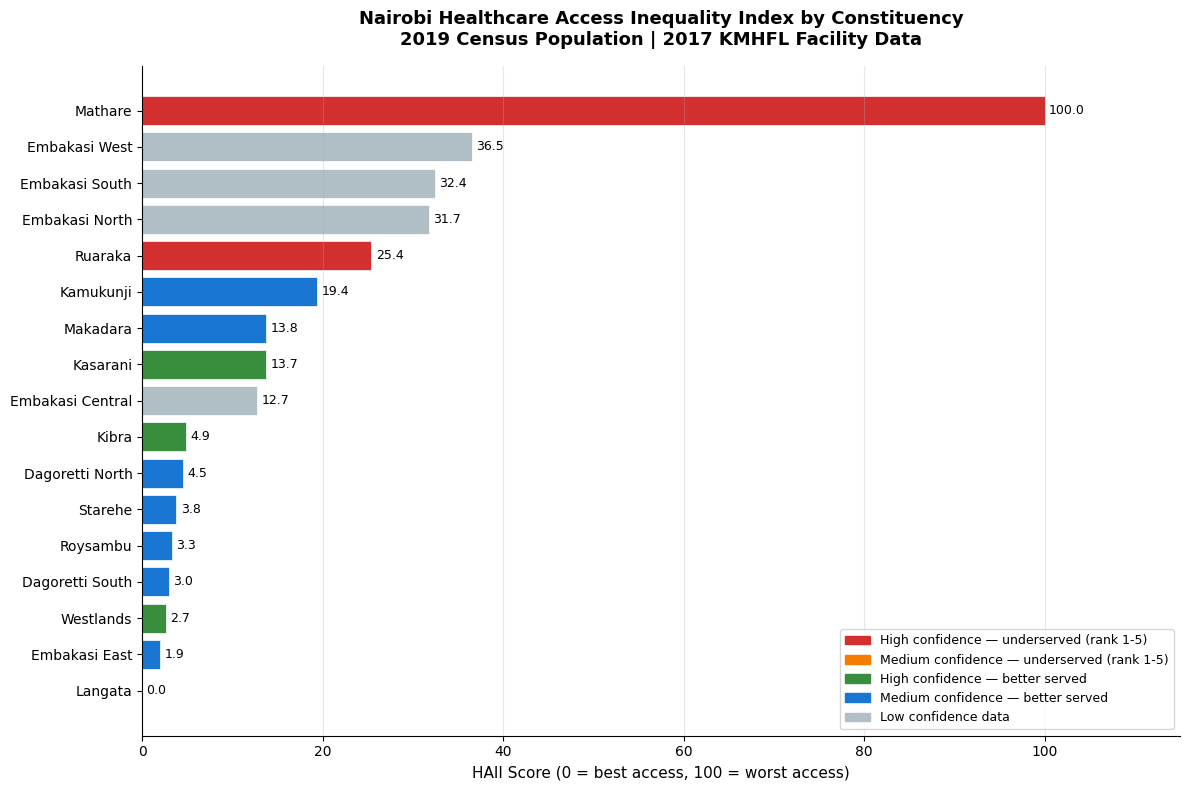

Ranking chart saved.


In [13]:
# CELL 7 — RANKING BAR CHART

fig, ax = plt.subplots(figsize=(12, 8))

colors = []
for _, row in master.iterrows():
    if row['confidence'] == 'high':
        colors.append('#d32f2f' if row['rank'] <= 5 else '#388e3c')
    elif row['confidence'] == 'medium':
        colors.append('#f57c00' if row['rank'] <= 5 else '#1976d2')
    else:
        colors.append('#b0bec5')

bars = ax.barh(
    master['constituency'],
    master['HAII_normalised'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add value labels
for bar, val in zip(bars, master['HAII_normalised']):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}',
        va='center',
        fontsize=9
    )

ax.set_xlabel('HAII Score (0 = best access, 100 = worst access)', fontsize=11)
ax.set_title(
    'Nairobi Healthcare Access Inequality Index by Constituency\n'
    '2019 Census Population | 2017 KMHFL Facility Data',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xlim(0, 115)
ax.invert_yaxis()

legend_elements = [
    mpatches.Patch(color='#d32f2f', label='High confidence — underserved (rank 1-5)'),
    mpatches.Patch(color='#f57c00', label='Medium confidence — underserved (rank 1-5)'),
    mpatches.Patch(color='#388e3c', label='High confidence — better served'),
    mpatches.Patch(color='#1976d2', label='Medium confidence — better served'),
    mpatches.Patch(color='#b0bec5', label='Low confidence data'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
chart_path = os.path.join(VISUALS_PATH, "04_haii_ranking_chart.png")
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print("Ranking chart saved.")

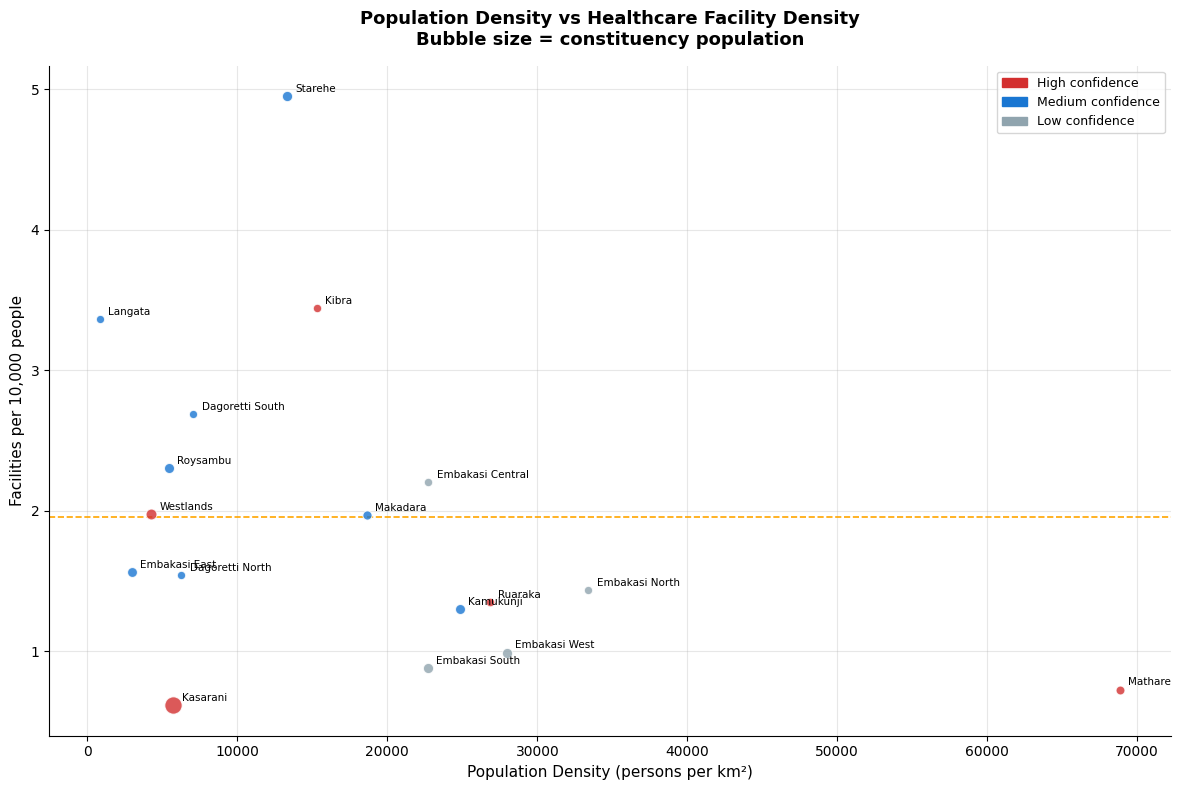

Scatter plot saved.


In [14]:
# CELL 8 — SCATTER PLOT: POPULATION DENSITY VS FACILITY DENSITY

fig, ax = plt.subplots(figsize=(12, 8))

confidence_colors = {
    'high'  : '#d32f2f',
    'medium': '#1976d2',
    'low'   : '#90a4ae'
}

for _, row in master.iterrows():
    color = confidence_colors[row['confidence']]
    ax.scatter(
        row['density_per_sqkm'],
        row['facility_density'],
        color=color,
        s=row['total_pop'] / 5000,
        alpha=0.8,
        edgecolors='white',
        linewidth=0.8,
        zorder=3
    )
    ax.annotate(
        row['constituency'],
        xy=(row['density_per_sqkm'], row['facility_density']),
        xytext=(6, 3),
        textcoords='offset points',
        fontsize=7.5,
        color='black'
    )

# Reference line — Nairobi average facility density
avg_density = master['facility_density'].mean()
ax.axhline(
    y=avg_density,
    color='orange',
    linestyle='--',
    linewidth=1.2,
    label=f'Nairobi avg facility density ({avg_density:.2f} per 10k)'
)

ax.set_xlabel('Population Density (persons per km²)', fontsize=11)
ax.set_ylabel('Facilities per 10,000 people', fontsize=11)
ax.set_title(
    'Population Density vs Healthcare Facility Density\n'
    'Bubble size = constituency population',
    fontsize=13, fontweight='bold', pad=15
)

legend_elements = [
    mpatches.Patch(color='#d32f2f', label='High confidence'),
    mpatches.Patch(color='#1976d2', label='Medium confidence'),
    mpatches.Patch(color='#90a4ae', label='Low confidence'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
scatter_path = os.path.join(VISUALS_PATH, "05_density_scatter.png")
plt.savefig(scatter_path, dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot saved.")